In [1]:
import math

## Градиентный спуск с фиксированным размером шага

In [2]:
def gradient_descent(f, f1, x0, a = 0.01, eps=1e-3, max_iter=100):
    x = x0
    f_x = f(x)
    func_calls = 1
    history_x = [x]      
    history_f = [f_x] 
    
    for iteration in range(max_iter):
        grad = f1(x)

        x_new = x - a * grad   #новая точка
        f_new = f(x_new)
        func_calls += 1

        # Проверка на расхождение
        if f_new > f_x:
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False

        if abs(x_new - x) < eps:
            history_x.append(x_new)
            history_f.append(f_new)
            return x_new, f_new, iteration + 1, func_calls, history_x, history_f, True

        x = x_new
        f_x = f_new        
        history_x.append(x)
        history_f.append(f_x)
        
    return x, f_x, iteration + 1, func_calls, history_x, history_f, False

## Размер шага корректируется в соответствии с размером второй производной 

In [3]:
def gradient_descent_plain(f, f1, f2, x0, eps=1e-3, max_iter=100):
    x = x0
    f_x = f(x)
    func_calls = 1
    history_x = [x]
    history_f = [f_x]
    for iteration in range(max_iter):
        grad = f1(x)
        hess = f2(x)
        if hess == 0:
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False
        step = grad / hess
        if not math.isfinite(step):
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False
        x_new = x - step
        f_new = f(x_new)
        func_calls += 1
        if f_new > f_x:
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False
        if abs(x_new - x) < eps:
            history_x.append(x_new)
            history_f.append(f_new)
            return x_new, f_new, iteration + 1, func_calls, history_x, history_f, True
        x = x_new
        f_x = f_new
        history_x.append(x)
        history_f.append(f_x)
    return x, f_x, iteration + 1, func_calls, history_x, history_f, False



### Версия с дроблением шага в проверке на расхождение. Шаг уменьгается пока f не станет убывать.

In [4]:

def gradient_descent_backtrack(f, f1, f2, x0, eps=1e-3, max_iter=100):
    x = x0
    f_x = f(x)
    func_calls = 1
    history_x = [x]
    history_f = [f_x]
    for iteration in range(max_iter):
        grad = f1(x)
        hess = f2(x)
        if hess == 0:
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False
        step = grad / hess
        if not math.isfinite(step):
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False
        x_new = x - step
        f_new = f(x_new)
        func_calls += 1
        t = 1.0
        while f_new > f_x:
            t *= 0.5
            if t < 1e-12:
                return x, f_x, iteration + 1, func_calls, history_x, history_f, False
            x_new = x - t * step
            f_new = f(x_new)
            func_calls += 1
        if abs(x_new - x) < eps:
            history_x.append(x_new)
            history_f.append(f_new)
            return x_new, f_new, iteration + 1, func_calls, history_x, history_f, True
        x = x_new
        f_x = f_new
        history_x.append(x)
        history_f.append(f_x)
    return x, f_x, iteration + 1, func_calls, history_x, history_f, False


In [5]:
def f(x):
    return x ** 2

def f1(x):
    return 2 * x 

learning_rates = [0.01, 0.5, 1.1]
x0 = 3

for a in learning_rates:
   
    x, f_x, iteration, func_calls, history_x, history_f, success = gradient_descent(
        f, f1, x0, a, eps=1e-3, max_iter=100
    )
    success_str = "Да" if success else "Нет"
    print(f"Шаг: {a:<5} | x:{x:<5.4f} | Итерации: {iteration:<5} | Кол-во вызовов:{func_calls:<5} |{success_str:<15}")

Шаг: 0.01  | x:0.3979 | Итерации: 100   | Кол-во вызовов:101   |Нет            
Шаг: 0.5   | x:0.0000 | Итерации: 2     | Кол-во вызовов:3     |Да             
Шаг: 1.1   | x:3.0000 | Итерации: 1     | Кол-во вызовов:2     |Нет            


### График: три траектории с постоянным шагом η

Траектории взяты из истории поиска (`history_x`, `history_f`). Красная стрелка — направление при η = 0.5, зелёная пунктирная — перескок при η = 1.1: метод отказался, и эта точка в истории отсутствует, поэтому дорисована отдельно.

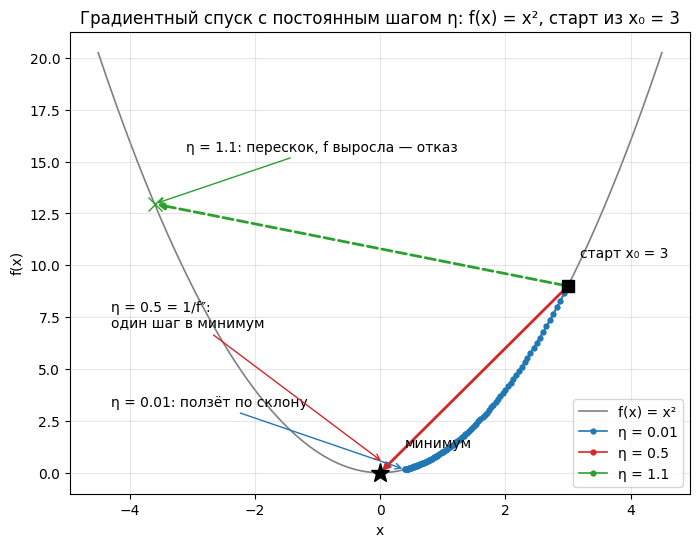

In [6]:
import matplotlib.pyplot as plt

learning_rates = [0.01, 0.5, 1.1]
colors = ["#1f77b4", "#d62728", "#2ca02c"]

xs = [i / 100 for i in range(-450, 451)]
ys = [x ** 2 for x in xs]

plt.figure(figsize=(8, 6))
plt.plot(xs, ys, color="gray", linewidth=1.2, zorder=1, label="f(x) = x²")

for a, color in zip(learning_rates, colors):
    x, f_x, iteration, func_calls, history_x, history_f, success = gradient_descent(
        f, f1, x0, a, eps=1e-3, max_iter=100
    )
    plt.plot(history_x, history_f, color=color, marker="o",
             markersize=3.5, linewidth=1.2, zorder=3, label=f"η = {a}")

plt.annotate("", xy=(0.0, 0.0), xytext=(3, 9),
             arrowprops=dict(arrowstyle="-|>", color="#d62728", lw=2))

x_rej = x0 - 1.1 * f1(x0)
f_rej = f(x_rej)
plt.annotate("", xy=(x_rej, f_rej), xytext=(3, 9),
             arrowprops=dict(arrowstyle="-|>", color="#2ca02c", lw=2, linestyle="--"))
plt.plot([x_rej], [f_rej], "x", color="#2ca02c", ms=10, zorder=4)

plt.plot([3], [9], marker="s", color="black", ms=8, zorder=5)
plt.plot([0], [0], marker="*", color="black", ms=14, zorder=5)

plt.annotate("старт x₀ = 3", xy=(3, 9), xytext=(3.2, 10.4), fontsize=10)
plt.annotate("минимум", xy=(0, 0), xytext=(0.4, 1.2), fontsize=10)
plt.annotate("η = 0.01: ползёт по склону", xy=(0.3979, 0.1583),
             xytext=(-4.3, 3.2), fontsize=10,
             arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=1))
plt.annotate("η = 0.5 = 1/f″:\nодин шаг в минимум", xy=(0.05, 0.5),
             xytext=(-4.3, 7.0), fontsize=10,
             arrowprops=dict(arrowstyle="->", color="#d62728", lw=1))
plt.annotate("η = 1.1: перескок, f выросла — отказ", xy=(x_rej, f_rej),
             xytext=(-3.1, 15.5), fontsize=10,
             arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1))

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Градиентный спуск с постоянным шагом η: f(x) = x², старт из x₀ = 3")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**Задание — ответ напиши сама, текстом.** Для η = 0.5 объясни, что происходит за один шаг и почему. Подсказка: у f(x) = x² вторая производная f″ = 2, то есть η = 0.5 — это ровно 1/f″. Что в этом случае за шаг делает постоянный η и чем он тогда является по сути?

Ответ: По сути это нахождение точки по методу ньютона. по формуле получается: новая точка = 3 - 0.5 * 2 * 3 = 0, мы сразу попадаем в минимум.  η·f′(x) = (1/f″)·f′(x) = f′(x)/f″(x) — это и есть шаг Ньютона.

In [7]:

# 0. Путь через дорогу и лес
def f_0(x):   return x / 4.0 + math.sqrt((8.0 - x) ** 2 + 9.0) / 3.0
def d1_0(x):  return (4*x + 3*math.sqrt((x - 8)**2 + 9) - 32) / (12*math.sqrt((x - 8)**2 + 9))
def d2_0(x):  return 3 / ((x - 8)**2 + 9)**1.5

# 1. Цилиндрическая банка 0.5 л
def f_1(r):   return 1000 / r + 2 * math.pi * r ** 2
def d1_1(r):  return 4 * math.pi * r - 1000 / r**2
def d2_1(r):  return 4 * math.pi + 2000 / r**3

# 2. Загон у реки (200 м сетки) — максимум, минус
def f_2(x):   return -(200 * x - 2 * x**2)
def d1_2(x):  return 4 * x - 200
def d2_2(x):  return 4

# 3. Коробка из листа 30x30 — максимум, минус
def f_3(h):   return -(900*h - 120*h**2 + 4*h**3)
def d1_3(h):  return -12 * h**2 + 240 * h - 900
def d2_3(h):  return 240 - 24 * h

# 4. Цена кофе (макс. выручка) — максимум, минус
def f_4(a):   return -(150 + 10*a) * (100 - 5*a)
def d1_4(a):  return 100 * a - 250
def d2_4(a):  return 100

# 5. EOQ: размер партии товара
def f_5(q):   return 2880000 / q + 1.5 * q
def d1_5(q):  return 1.5 - 2880000 / q**2
def d2_5(q):  return 5760000 / q**3

# 6. Балка из бревна d 30 см — максимум, минус
def f_6(a):   return -math.sqrt(900 - a**2) * a**2
def d1_6(a):  return 3 * a * (a**2 - 600) / math.sqrt(900 - a**2)
def d2_6(a):  return 6 * math.sqrt(900 - a**2) * (-a**4 + 1350*a**2 - 270000) / (a**4 - 1800*a**2 + 810000)

# 7. Лампа над круглым столом — максимум, минус
def f_7(h):   return -(h / (h**2 + 1)**1.5)
def d1_7(h):  return (2 * h**2 - 1) / (h**2 + 1)**2.5
def d2_7(h):  return -3 * h * (2 * h**2 - 3) / (h**2 + 1)**3.5

# 8. Жёлоб из полосы 30 см — максимум, минус
def f_8(t):   return -(225 * math.sin(t) / (2 - math.cos(t)))
def d1_8(t):  return 225 * (1 - 2 * math.cos(t)) / (math.cos(t) - 2)**2
def d2_8(t):  return -450 * (math.cos(t) + 1) * math.sin(t) / (math.cos(t) - 2)**3

# 9. Кровеносный сосуд (Пуазейль)
def f_9(t):   return (16 - math.cos(t)) / math.sin(t)
def d1_9(t):  return (1 - 16 * math.cos(t)) / math.sin(t)**2
def d2_9(t):  return (-16 * math.sin(t)**2 - 2 * math.cos(t) + 32) / math.sin(t)**3

# 10. Нормандское окно (P=6 м) — максимум, минус
def f_10(r):  return -(6*r - (2 + math.pi / 2)*r**2)
def d1_10(r): return (4 + math.pi) * r - 6
def d2_10(r): return 4 + math.pi


In [8]:
x, f_new, iteration, func_calls, history_x, history_f, success = gradient_descent_plain(f_0, d1_0, d2_0, 3, eps=1e-3, max_iter=100)
print(x, f_new)

x, f_new, iteration, func_calls, history_x, history_f, success = gradient_descent_plain(f_5, d1_5, d2_5, 1500, eps=1e-3, max_iter=100)
print(x, f_new)

x, f_new, iteration, func_calls, history_x, history_f, success = gradient_descent_plain(f_10, d1_10, d2_10, 0.5, eps=1e-3, max_iter=100)
print(x, f_new)

4.598319742921439 2.661437827766148
1385.6406460550984 4156.921938165306
0.840148730267336 -2.520446190802008


### Сравнение: постоянный шаг против шага 1/f″ на всех 11 задачах

Для каждой задачи постоянный η подобран как `1/f″` в точке минимума (аналитический ответ) — это лучший постоянный шаг, какой можно придумать: в минимуме он совпадает с ньютоновским. Вопрос: что остаётся от выигрыша адаптивного шага, если постоянный уже оптимальный?

In [9]:
eps = 1e-3

tasks = [
    ("0. Дорога/лес", f_0,  d1_0,  d2_0,  4.0,    8 - math.sqrt(81/7)),
    ("1. Банка",      f_1,  d1_1,  d2_1,  5.0,    (250/math.pi)**(1/3)),
    ("2. Загон",      f_2,  d1_2,  d2_2,  25.0,   50.0),
    ("3. Коробка",    f_3,  d1_3,  d2_3,  3.0,    5.0),
    ("4. Кофе",       f_4,  d1_4,  d2_4,  2.0,    2.5),
    ("5. EOQ",        f_5,  d1_5,  d2_5,  1500.0, 800*math.sqrt(3)),
    ("6. Балка",      f_6,  d1_6,  d2_6,  24.5,   10*math.sqrt(6)),
    ("7. Лампа",      f_7,  d1_7,  d2_7,  0.5,    1/math.sqrt(2)),
    ("8. Жёлоб",      f_8,  d1_8,  d2_8,  1.0,    math.pi/3),
    ("9. Сосуд",      f_9,  d1_9,  d2_9,  1.5,    math.acos(1/16)),
    ("10. Окно",      f_10, d1_10, d2_10, 0.5,    6/(4+math.pi)),
]

print(f"{'Задача':<13}{'η = 1/f″(x*)':>13}{'фикс. ит.':>13}{'фикс. ok':>13}{'1/f″ ит.':>13}{'1/f″ ok':>13}")
print("-" * 80)
for name, f, f1, f2, x0, xs in tasks:
    eta = 1.0 / f2(xs)
    xf, _, itf, _, _, _, okf = gradient_descent(f, f1, x0, eta, eps=eps, max_iter=100)
    xp, _, itp, _, _, _, okp = gradient_descent_plain(f, f1, f2, x0, eps=eps, max_iter=100)
    print(f"{name:<13}{eta:>13.5g}{itf:>11}{str(okf):>13}{itp:>11}{str(okp):>13}")

Задача        η = 1/f″(x*)    фикс. ит.     фикс. ok     1/f″ ит.      1/f″ ok
--------------------------------------------------------------------------------
0. Дорога/лес       31.101          4         True          4         True
1. Банка          0.026526          4         True          4         True
2. Загон              0.25          2         True          2         True
3. Коробка       0.0083333          4         True          4         True
4. Кофе               0.01          2         True          2         True
5. EOQ              461.88          4         True          4         True
6. Балка         0.0048113          2         True          2         True
7. Лампа           0.97428          4         True          4         True
8. Жёлоб         0.0057735          3         True          3         True
9. Сосуд          0.062378          2         True          2         True
10. Окно           0.14002          2         True          2         True


### Один и тот же η на все задачи — можно ли?

В таблице выше η у задач отличается в десятки тысяч раз (0.008 у коробки, 462 у EOQ). Проверим, что получится, если взять одно и то же η для всех одиннадцати задач.

In [10]:
print("Одно η на все 11 задач (0–10): сошёлся / не сошёлся за 100 итераций")
print()
for eta in [0.01, 0.5, 500.0]:
    ok_list, fail_list = [], []
    for name, f, f1, f2, x0, xs in tasks:
        try:
            xf, _, itf, _, _, _, okf = gradient_descent(f, f1, x0, eta, eps=eps, max_iter=100)
        except Exception:
            okf, itf = False, "взрыв"
        if okf:
            ok_list.append(name.split(".")[1].strip())
        else:
            fail_list.append(f"{name.split('.')[1].strip()}({itf})")
    print(f"η = {eta}: сошлось {len(ok_list)}/11; не сошлось: {', '.join(fail_list)}")
    print()

Одно η на все 11 задач (0–10): сошёлся / не сошёлся за 100 итераций

η = 0.01: сошлось 8/11; не сошлось: Загон(100), EOQ(100), Балка(1)

η = 0.5: сошлось 1/11; не сошлось: Дорога/лес(100), Банка(2), Загон(100), Коробка(взрыв), Кофе(1), EOQ(100), Балка(1), Жёлоб(1), Сосуд(1), Окно(1)

η = 500.0: сошлось 1/11; не сошлось: Дорога/лес(1), Банка(1), Загон(1), Коробка(взрыв), Кофе(1), Балка(взрыв), Лампа(1), Жёлоб(1), Сосуд(3), Окно(1)



**Вывод по прогону**

- С лучшим постоянным шагом η = 1/f″(x*) спуск сходится так же быстро, как с адаптивным: обе версии укладываются в 2–4 итерации на всех одиннадцати задачах. Прежнее сравнение было записано без прогона и являлось предположительным.
- Проблема в том, что η не ставится случайно, для поиска лучшего постоянного шага необходимо знать кривизну в точке минимума и подбирать размер шага под каждую конкретную задачу отдельно. Причём «идеальные» шаги для задач отличаются в десятки тысяч раз - разброс составляет от 0.008 (задача "Коробка") до 462 (задача "EOQ").
- Таким образом преимущества адаптивного шага заключается в том, что он этого подбора не требует и сам ищет оптимальный размер шага. Его ограничение в том, что данный способ применим когда мы можем вычислить вторую производную. 

# Градиентный спуск для двумерной функции

In [11]:
def gradient_descent_2d_numer(f, x1, x2, a=0.01, eps=1e-3, max_iter=100, h=1e-6, guard=True):
    x = [x1, x2]
    
    def numerical_grad(x1, x2):
        grad1 = (f(x1 + h, x2) - f(x1 - h, x2)) / (2 * h)
        grad2 = (f(x1, x2 + h) - f(x1, x2 - h)) / (2 * h)
        return [grad1, grad2]
    
    f_x = f(x[0], x[1])
    func_calls = 1
    history_x = [(x1, x2)]  
    history_f = [f_x] 
    
    for iteration in range(max_iter):
        grad = numerical_grad(x[0], x[1])
        func_calls += 4 

        # Обновляем координаты
        x_new1 = x[0] - a * grad[0]
        x_new2 = x[1] - a * grad[1]
        
        f_new = f(x_new1, x_new2)
        func_calls += 1

        # Проверка на расхождение (управляется флагом guard)
        if guard and f_new > f_x:
            return x[0], x[1], f_x, iteration + 1, func_calls, history_x, history_f, False  

        grad_norm = math.hypot(grad[0], grad[1])
        if grad_norm < eps:
            history_x.append((x_new1, x_new2))
            history_f.append(f_new)
            return x_new1, x_new2, f_new, iteration + 1, func_calls, history_x, history_f, True

        x = [x_new1, x_new2]
        f_x = f_new        
        history_x.append((x_new1, x_new2))
        history_f.append(f_x)
        
    return x[0], x[1], f_x, iteration + 1, func_calls, history_x, history_f, False

In [12]:
def f(x1, x2):
    return x1 ** 2 + 2 * x2 ** 2

x_new1, x_new2, f_new, iteration, func_calls, history_x, history_f, success = gradient_descent_2d_numer(
    f, 4, 3, a=0.01, eps=1e-3, max_iter=100, h=1e-6
)

print(f"Точка: ({x_new1:.4f}, {x_new2:.4f})")
print(f"f = {f_new}")
print(success)
print(f"func_calls: {func_calls}: iteration {iteration}")
print()
x_new1, x_new2, f_new, iteration, func_calls, history_x, history_f, success = gradient_descent_2d_numer(
    f, 4, 3, a=0.25, eps=1e-3, max_iter=100, h=1e-6
)

print(f"Точка: ({x_new1:.4f}, {x_new2:.4f})")
print(f"f = {f_new}")
print(success)
print(f"func_calls: {func_calls}: iteration {iteration}")

Точка: (0.5305, 0.0506)
f = 0.28653008382384143
False
func_calls: 501: iteration 100

Точка: (0.0002, 0.0000)
f = 5.960464476477963e-08
True
func_calls: 71: iteration 14


### Обязательный эксперимент: три шага на одном графике линий уровня

Три траектории на одних осях, чтобы три поведения были сравнимы: ползёт, идёт нормально, перескакивает. Функция `f = x1^2 + 2x2^2`, кривизны по осям 2 и 4, граница устойчивости `a < 2/4 = 0.5`, старт из `(4, 3)`:

- `a = 0.01` — шаг слишком мал: ползёт, за 100 итераций не успевает сойтись (`success=False`);
- `a = 0.25` — нормальный шаг: сходится к `(0, 0)`;
- `a = 0.6` — выше границы 0.5: перескакивает, на первом же шаге `f` выросла, защита отклонила шаг. Отклонённая точка дорисована крестиком.

Траектории (последовательность точек из `history_x`) наложены на линии уровня `f`. Из-за разных кривизн по осям спуск идёт к минимуму ломаной, а не по прямой.

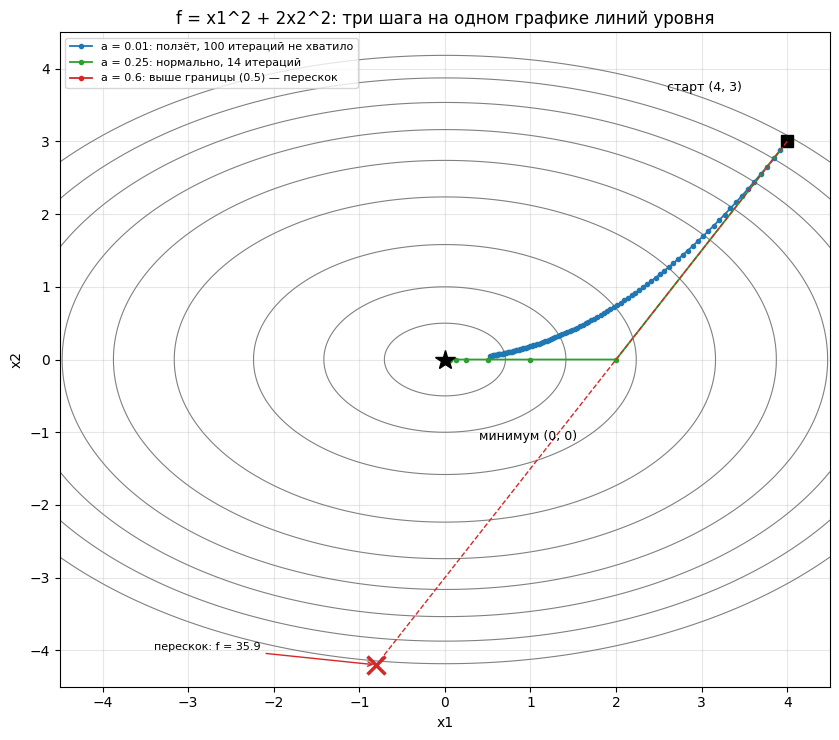

In [13]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x1, x2: x1**2 + 2*x2**2

xs = np.linspace(-4.5, 4.5, 400)
ys = np.linspace(-4.5, 4.5, 400)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)
levels = [0.5, 2, 5, 10, 15, 20, 25, 30, 35]

steps = [0.01, 0.25, 0.6]
colors = ["#1f77b4", "#2ca02c", "#d62728"]

# прогоняем все три шага заранее, чтобы в подписи были настоящие числа итераций
res = {}
for a in steps:
    res[a] = gradient_descent_2d_numer(f, 4, 3, a=a, eps=1e-3, max_iter=100, h=1e-6)

labels = {
    0.01: "a = 0.01: ползёт, 100 итераций не хватило",
    0.25: None,  # соберём из результата
    0.6:  "a = 0.6: выше границы (0.5) — перескок",
}

plt.figure(figsize=(8.5, 7.5))
plt.contour(X, Y, Z, levels=levels, colors="gray", linewidths=0.8)

for a, color in zip(steps, colors):
    x1, x2, fv, it, fc, hx, hf, ok = res[a]
    if a == 0.25:
        lbl = f"a = 0.25: нормально, {it} итераций"
    else:
        lbl = labels[a]
    hx_arr = np.array(hx)
    plt.plot(hx_arr[:, 0], hx_arr[:, 1], color=color, marker="o",
             markersize=3, linewidth=1.3, label=lbl)

# старт и минимум
plt.plot(4, 3, marker="s", color="k", ms=8)
plt.plot(0, 0, marker="*", color="k", ms=15)
plt.annotate("старт (4, 3)", xy=(4, 3), xytext=(2.6, 3.7), fontsize=9)
plt.annotate("минимум (0, 0)", xy=(0, 0), xytext=(0.4, -1.1), fontsize=9)

# отклонённый перескок для a = 0.6: его нет в истории — дорисовываем отдельной точкой
a_rej = 0.6
xr1 = 4 - a_rej * (2 * 4)      # градиент f по x1 в старте
xr2 = 3 - a_rej * (4 * 3)      # градиент f по x2 в старте
fr = f(xr1, xr2)
plt.plot([4, xr1], [3, xr2], color="#d62728", linestyle="--", linewidth=1)
plt.plot(xr1, xr2, marker="x", color="#d62728", ms=13, mew=2.5)
plt.annotate(f"перескок: f = {fr:.1f}", xy=(xr1, xr2),
             xytext=(-3.4, -4.0), fontsize=8,
             arrowprops=dict(arrowstyle="->", color="#d62728", lw=1))

plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(-4.5, 4.5)
plt.ylim(-4.5, 4.5)
plt.title("f = x1^2 + 2x2^2: три шага на одном графике линий уровня")
plt.legend(loc="upper left", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
def gradient_descent_2d_analit(f, f1, x1, x2, a=0.01, eps=1e-3, max_iter=100, guard=True):
    x = [x1, x2]
    
    f_x = f(x[0], x[1])
    func_calls = 1
    history_x = [(x1, x2)]  
    history_f = [f_x] 
    
    for iteration in range(max_iter):
        # Аналитический градиент
        grad = f1(x[0], x[1])
       
        # Обновляем координаты
        x_new1 = x[0] - a * grad[0]
        x_new2 = x[1] - a * grad[1]
        
        f_new = f(x_new1, x_new2)
        func_calls += 1

        # Проверка на расхождение (управляется флагом guard)
        if guard and f_new > f_x:
            return x[0], x[1], f_x, iteration + 1, func_calls, history_x, history_f, False

        grad_norm = math.hypot(grad[0], grad[1])
        if grad_norm < eps:
            history_x.append((x_new1, x_new2))
            history_f.append(f_new)
            return x_new1, x_new2, f_new, iteration + 1, func_calls, history_x, history_f, True

        x = [x_new1, x_new2]
        f_x = f_new        
        history_x.append((x_new1, x_new2))
        history_f.append(f_x)
        
    return x[0], x[1], f_x, iteration + 1, func_calls, history_x, history_f, False

In [15]:
def f(x1, x2):
    return x1 ** 2 + 2 * x2 ** 2

def f1(x1, x2):
    return [2 * x1, 4 * x2]

x_new1, x_new2, f_x, iteration, func_calls, history_x, history_f, success = gradient_descent_2d_analit(
    f, f1, 4, 3, a=0.01, eps=1e-3, max_iter=100
)

print(f"Точка: ({x_new1:.4f}, {x_new2:.4f})")
print(f"f = {f_x}")
print(success)
print(f"func_calls: {func_calls}: iteration {iteration}")
print()
x_new1, x_new2, f_x, iteration, func_calls, history_x, history_f, success = gradient_descent_2d_analit(
    f, f1, 4, 3, a=0.25, eps=1e-3, max_iter=100
)

print(f"Точка: ({x_new1:.4f}, {x_new2:.4f})")
print(f"f = {f_x}")
print(success)
print(f"func_calls: {func_calls}: iteration {iteration}")

Точка: (0.5305, 0.0506)
f = 0.2865300838463973
False
func_calls: 101: iteration 100

Точка: (0.0002, 0.0000)
f = 5.960464477539063e-08
True
func_calls: 15: iteration 14


## Работа методов на функции: x₁² + 3·x₂²

In [16]:
def f(x1, x2):
    return x1 ** 2 + 3 * x2 ** 2

def f1(x1, x2):
    return [2 * x1, 6 * x2]

learning_rates = [0.01, 0.5, 1.1]

for a in learning_rates:

    #Вариант с аналитическим вычислением градиента
    x_new1, x_new2, f_x, iteration, func_calls, history_x, history_f, success = gradient_descent_2d_analit(
        f, f1, 3, 3, a, eps=1e-3, max_iter=100
    )
    print(f"point: ({x_new1:.4f}, {x_new2:.4f}) | step: {a}")
    print(f"f = {f_x}")
    print(success)
    print(f"func_calls: {func_calls}: iteration {iteration}")
    print()

    #Вариант с численным вычислением градиента
    x_new1, x_new2, f_x, iteration, func_calls, history_x, history_f, success = gradient_descent_2d_numer(
        f, 3, 3, a, eps=1e-3, max_iter=100, h=1e-6
    )
    print(f"point: ({x_new1:.4f}, {x_new2:.4f}) | step: {a}")
    print(f"f = {f_x}")
    print(success)
    print(f"func_calls: {func_calls}: iteration {iteration}")
    print()


point: (0.3979, 0.0062) | step: 0.01
f = 0.15840552723020257
False
func_calls: 101: iteration 100

point: (0.3979, 0.0062) | step: 0.01
f = 0.15840552722592469
False
func_calls: 501: iteration 100

point: (3.0000, 3.0000) | step: 0.5
f = 36
False
func_calls: 2: iteration 1

point: (3.0000, 3.0000) | step: 0.5
f = 36
False
func_calls: 6: iteration 1

point: (3.0000, 3.0000) | step: 1.1
f = 36
False
func_calls: 2: iteration 1

point: (3.0000, 3.0000) | step: 1.1
f = 36
False
func_calls: 6: iteration 1



### Сравнение результатов в таблице

Функция `f = x1^2 + 3x2^2`, старт из `(3, 3)`, `eps = 1e-3`, `max_iter = 100`. Собственные числа Гессе: `lambda_1 = 2`, `lambda_2 = 6`, поэтому теоретическая граница сходимости — `a < 2 / 6 = 0.333`.

Из трёх шагов только `a = 0.01` ниже границы (но он слишком мал и за 100 итераций не успевает); `a = 0.5` и `a = 1.1` — выше границы, должны расходиться.

Аналитический градиент: `[2*x1, 6*x2]`. Численный — центральной разностью с `h = 1e-6` (4 вызова функции на шаг вместо 1 у аналитического).

In [17]:
def f(x1, x2):
    return x1 ** 2 + 3 * x2 ** 2

def f1(x1, x2):
    return [2 * x1, 6 * x2]

steps = [0.01, 0.5, 1.1, 0.2287, 0.25]
max_iter = 100
eps = 1e-3

print(f"{'a':<6}{'метод':<12}{'точка (x1, x2)':<22}{'f':<14}{'итер':<6}{'вызовы f':<10}{'success'}")
print("-" * 78)

for a in steps:
    # аналитический градиент
    x1, x2, fv, it, fc, _, _, ok = gradient_descent_2d_analit(f, f1, 3, 3, a=a, eps=eps, max_iter=max_iter)
    print(f"{a:<6}{'аналит':<12}({x1:>8.4f},{x2:>8.4f}){fv:<14.6g}{it:<6}{fc:<10}{ok}")
    # численный градиент
    x1, x2, fv, it, fc, _, _, ok = gradient_descent_2d_numer(f, 3, 3, a=a, eps=eps, max_iter=max_iter)
    print(f"{a:<6}{'числен':<12}({x1:>8.4f},{x2:>8.4f}){fv:<14.6g}{it:<6}{fc:<10}{ok}")
    print()

a     метод       точка (x1, x2)        f             итер  вызовы f  success
------------------------------------------------------------------------------
0.01  аналит      (  0.3979,  0.0062)0.158406      100   101       False
0.01  числен      (  0.3979,  0.0062)0.158406      100   501       False

0.5   аналит      (  3.0000,  3.0000)36            1     2         False
0.5   числен      (  3.0000,  3.0000)36            1     6         False

1.1   аналит      (  3.0000,  3.0000)36            1     2         False
1.1   числен      (  3.0000,  3.0000)36            1     6         False

0.2287аналит      (  0.0002,  0.0000)2.86816e-08   16    17        True
0.2287числен      (  0.0002,  0.0000)2.86816e-08   16    81        True

0.25  аналит      (  0.0000,  0.0000)8.3819e-09    16    17        True
0.25  числен      (  0.0000,  0.0000)8.3819e-09    16    81        True



Вывод: по целому числу итераций нельзя выбирать «лучший» с точностью до третьего знака — 0.2287 и 0.25 здесь неразличимы

Из сравнения результатов решения функции с использованием численного и аналитического способа получения производной видно, что численный способ получения производных требует значительно большего числа вызовов целевой функции. 

В общем случае для d переменных: на каждой итерации численный градиент требует `2d` вызовов функции. по два на каждую координату плюс один вызов в новой точке после шага. Итого `2d + 1` вызовов на итерацию.

То есть, например, для 1000 параметров на каждой итерации нужно 2001 вызов функции вместо одного. 

### Кривые сходимости: прежние шаги + найденный перебором

По горизонтали — номер итерации, по вертикали — значение функции `f` (логарифмическая шкала). Аналитический градиент.

- `a = 0.01`: ползёт, за 100 итераций доходит только до `f ≈ 0.158` — не сошёлся.
- `a = 0.5` и `a = 1.1`: рост `f` на первой итерации — отказ. Крестиком дорисована отброшенная точка перескока.
- `a = 0.2287`: найден перебором по логарифмической сетке как лучший (минимум итераций среди сходящихся) — сходится к `(0, 0)` за 16 итераций. Видно, что его кривая падает быстрее всех остальных.

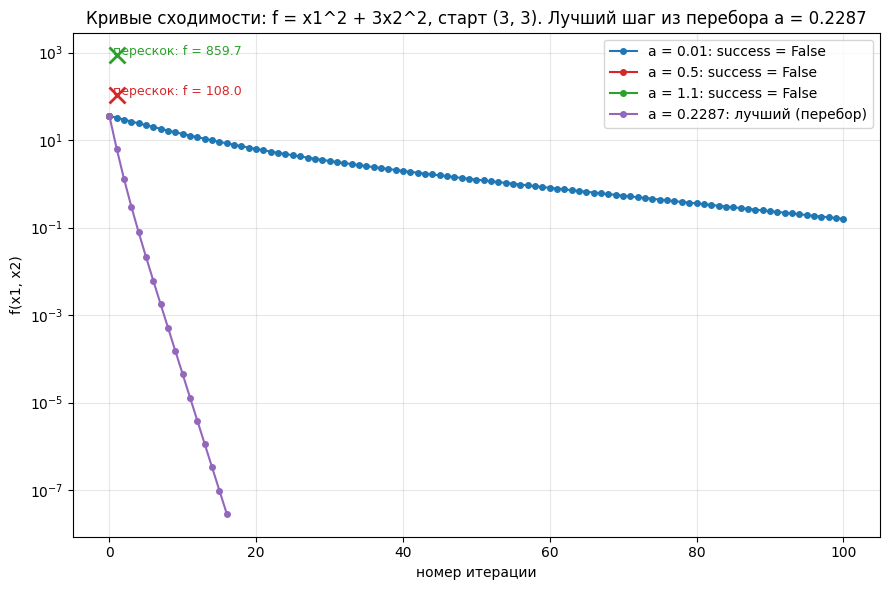

In [18]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x1, x2: x1**2 + 3*x2**2
f1 = lambda x1, x2: [2*x1, 6*x2]

steps = [0.01, 0.5, 1.1, 0.2287]
colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]

plt.figure(figsize=(9, 6))

for a, color in zip(steps, colors):
    x1, x2, fv, it, fc, hx, hf, ok = gradient_descent_2d_analit(f, f1, 3, 3, a=a, eps=1e-3, max_iter=100)
    iters = list(range(len(hf)))
    label = f"a = {a}: success = {ok}" if a != 0.2287 else f"a = {a}: лучший (перебор)"
    plt.plot(iters, hf, color=color, marker="o", markersize=4, linewidth=1.5, label=label)
    if not ok and len(hf) == 1:
        grad = f1(3, 3)
        xr1, xr2 = 3 - a * grad[0], 3 - a * grad[1]
        fr = f(xr1, xr2)
        plt.plot(1, fr, marker="x", color=color, ms=11, mew=2, zorder=4)
        plt.annotate(f"перескок: f = {fr:.1f}", xy=(1, fr), xytext=(0.55, fr),
                     color=color, fontsize=9)

plt.axhline(0, color="gray", linewidth=0.8)
plt.yscale("log")
plt.xlabel("номер итерации")
plt.ylabel("f(x1, x2)")
plt.title("Кривые сходимости: f = x1^2 + 3x2^2, старт (3, 3). Лучший шаг из перебора a = 0.2287")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
#поиск лучшего шага перебором
a_min, a_max = 0.01, 0.5
N = 20  #сколько точек проверить 

log_min = math.log10(a_min)  
log_max = math.log10(a_max)  

grid = []
for k in range(N + 1):
    log_a = log_min + k * (log_max - log_min) / N
    a = 10 ** log_a 
    grid.append(a)

best_a = None
best_iter =  math.inf

for a in grid:
    x1, x2, fv, iters, fc, hx, hf, ok = gradient_descent_2d_numer(f, 3, 3, a=a, eps=1e-3, max_iter=1000, h=1e-6)
    if ok and iters < best_iter:
        best_iter = iters
        best_a = a

#поиск лучшего шага через формулу
lambda_min, lambda_max = 2.0, 6.0
a_theory = 2 / (lambda_min + lambda_max)

print(f"Перебор:  a = {best_a:.4f}, итераций = {best_iter}")
print(f"Формула:  a = {a_theory:.4f}")
print()
step_log = (log_max - log_min) / N
close = abs(math.log10(best_a) - math.log10(a_theory)) 

if close < step_log:
    print(f"Совпали с точностью до шага сетки.")
else:
    print(f"Не совпали даже в пределах шага сетки. Разница: {abs(best_a - a_theory):.4f}")

Перебор:  a = 0.2287, итераций = 16
Формула:  a = 0.2500

Совпали с точностью до шага сетки.


### Сверка: градиентный спуск против случайного поиска на задаче про рынок

Функция из раздела 5 задачника: `f(x, y) = −(40x + 50y − x² − y² − xy)` — задача на максимум прибыли, поэтому минимизируем `f`. Минимум в точке `(10, 20)`. Гессе `[[2, 1], [1, 2]]`, кривизны `λ = 1, 3`, граница устойчивости `a < 2/3`, оптимальный шаг `2/(1 + 3) = 0.5`.

Прогоняем с одного старта два независимых метода: градиентный спуск и случайный поиск (тот же, что в разделе 5 задачника). Если оба сходятся к `(10, 20)` — два пути к одному числу подтверждают друг друга.

градиентный спуск: точка (10.000000, 20.000000), f = -700.0000, итераций = 27, ok = True
случайный поиск:   точка (10.199323, 19.760584), f = -699.9507
аналитический минимум: (10, 20), f = -700.0000
ошибка до (10, 20): спуск = 1.47e-07, случайный поиск = 3.12e-01


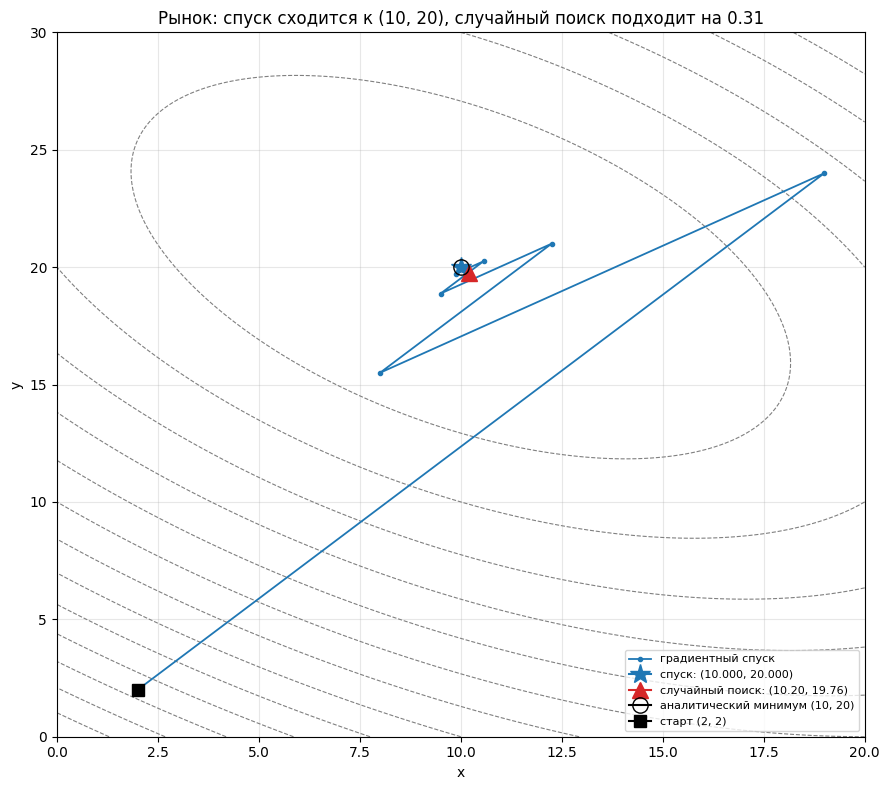

In [20]:
import random

def market(x, y):
    return - (40 * x + 50 * y - x ** 2 - y ** 2 - x * y)

def market_grad(x, y):
    return [2 * x + y - 40, 2 * y + x - 50]

def random_search(f, bounds, n_points, seed=None):
    rng = random.Random(seed)
    best_x, best_f = None, float('inf')
    for _ in range(n_points):
        x = tuple(rng.uniform(lo, hi) for (lo, hi) in bounds)
        val = f(x)
        if val < best_f:
            best_f, best_x = val, x
    return best_x, best_f

x_start, y_start = 2.0, 2.0

# 1) градиентный спуск (шаг 0.5 = 2/(1 + 3), eps по норме градиента)
x1, x2, fv, it, fc, hx, hf, ok = gradient_descent_2d_analit(
    market, market_grad, x_start, y_start, a=0.5, eps=1e-6, max_iter=100
)
err_desc = math.hypot(x1 - 10.0, x2 - 20.0)

# 2) случайный поиск (как в разделе 5 задачника: область 0..20 x 0..30, N = 5000)
bx, bf = random_search(lambda p: market(p[0], p[1]),
                       [(0.0, 20.0), (0.0, 30.0)], 5000, seed=1)
err_rand = math.hypot(bx[0] - 10.0, bx[1] - 20.0)

print(f"градиентный спуск: точка ({x1:.6f}, {x2:.6f}), f = {fv:.4f}, итераций = {it}, ok = {ok}")
print(f"случайный поиск:   точка ({bx[0]:.6f}, {bx[1]:.6f}), f = {bf:.4f}")
print(f"аналитический минимум: (10, 20), f = {market(10.0, 20.0):.4f}")
print(f"ошибка до (10, 20): спуск = {err_desc:.2e}, случайный поиск = {err_rand:.2e}")

# линии уровня + траектория спуска + обе найденные точки
XX = np.linspace(0, 20, 300)
YY = np.linspace(0, 30, 300)
Xm, Ym = np.meshgrid(XX, YY)
Zm = market(Xm, Ym)

plt.figure(figsize=(9, 8))
plt.contour(Xm, Ym, Zm, levels=np.linspace(-650, -50, 13),
            colors="gray", linewidths=0.8)

hx_arr = np.array(hx)
plt.plot(hx_arr[:, 0], hx_arr[:, 1], color="#1f77b4", marker="o",
         markersize=3, linewidth=1.3, label="градиентный спуск")
plt.plot(x1, x2, marker="*", color="#1f77b4", ms=15,
         label=f"спуск: ({x1:.3f}, {x2:.3f})")
plt.plot(bx[0], bx[1], marker="^", color="#d62728", ms=11,
         label=f"случайный поиск: ({bx[0]:.2f}, {bx[1]:.2f})")
plt.plot(10, 20, marker="o", color="k", mfc="none", ms=11,
         label="аналитический минимум (10, 20)")
plt.plot(x_start, y_start, marker="s", color="k", ms=8, label="старт (2, 2)")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Рынок: спуск сходится к (10, 20), случайный поиск подходит на 0.31")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Эксперимент с демонстрацией расхождения

В функцию добавлен флаг guard=False, который отключает проверку f_new > f_x. Сделано для того чтобы наглядно увидеть как метод расходится 

In [21]:
def f(x1, x2):
    return x1 ** 2 + 3 * x2 ** 2

def f1(x1, x2):
    return [2 * x1, 6 * x2]

In [23]:
steps_to_print = 10
steps = [0.32, 0.34]

for step in steps:
    print(f"Шаг a = {step}")
    
    x1, x2, fv, it, fc, hx, hf, ok = gradient_descent_2d_analit(
        f, f1, 3, 3, a=step, eps=1e-3, max_iter=steps_to_print, guard=False
    )
    for i, val in enumerate(hf):
        if i == 0:
            print(f"старт: f = {val:.4g}")
        else:
            print(f"итерация {i}: f = {val:.4g}")
        
    print(f"success = {ok}")


Шаг a = 0.32
старт: f = 36
итерация 1: f = 24.02
итерация 2: f = 19.49
итерация 3: f = 16.39
итерация 4: f = 13.86
итерация 5: f = 11.73
итерация 6: f = 9.927
итерация 7: f = 8.402
итерация 8: f = 7.112
итерация 9: f = 6.019
итерация 10: f = 5.095
success = False
Шаг a = 0.34
старт: f = 36
итерация 1: f = 30.12
итерация 2: f = 31.68
итерация 3: f = 34.17
итерация 4: f = 36.95
итерация 5: f = 39.97
итерация 6: f = 43.23
итерация 7: f = 46.76
итерация 8: f = 50.57
итерация 9: f = 54.7
итерация 10: f = 59.16
success = False


Граница устойчивости для этой функции - шаг примерно 0.333.
Всё, что меньше, должно сходиться. Всё, что больше — расходиться.

- Шаг 0.32 (метод сходится). Шаг достаточно мал, поэтому алгоритм постепенно спускается к минимуму, значение функции стабильно уменьшается.
- Шаг 0.34 (метод расходится). Мы  перешагнули критическую границу( a < 2/6 == 0.333). Функция растёт, метод расходится.
Таким образом граница устойчивости подтверждена экспериментально. x₂ за шаг *(1−6a), значит f *(1−6a)² = 0.846 при a=0.32 и 1.082 при a=0.34.